## Handling the Constraint

Assume the original space is
$$
S = \{x \in \mathbb{R}^n \mid \mathbf{1}^\top x = 1, l \preceq x \preceq h \}
$$
with $n > 1$, $\mathbf{0} \preceq l \prec h \preceq \mathbf{1}$.

We intend to construct a bi-projection $\phi$ such that
$$
S' = \{y \in \mathbb{R}^{n-1} \mid 0 \preceq y \preceq 1 \} = \phi(S)
$$

### Derivation

**Assumptions and feasibility**
- $S=\{x\in\mathbb{R}^n\mid \mathbf{1}^\top x=1,\; l\preceq x\preceq h\}$ with $n>1$ and $\mathbf{0}\preceq l\prec h\preceq\mathbf{1}$.
- $S\neq\varnothing$ iff $\sum_{i=1}^n l_i \le 1 \le \sum_{i=1}^n h_i$.

**Tail sums (fixed data)**. Define tail lower/upper sums for indices $k=1,\dots,n$:
  $$
  L_k \;=\; \sum_{i=k}^n l_i,\qquad H_k \;=\; \sum_{i=k}^n h_i.
  $$
  Note $L_1=\sum_{i=1}^n l_i,\ H_1=\sum_{i=1}^n h_i$.

**Sequential feasible interval for $x_k$.** Work left-to-right. Let $T_k$ be the remaining total before choosing $x_k$:
  $$
  T_k \;=\; 1-\sum_{i=1}^{k-1} x_i\qquad (T_1=1).
  $$
For $k=1,\dots,n-1$ the feasible interval for $x_k$ (so that a completion of the remaining components exists) is
  $$
\begin{align}
x_k &\in [a_k,b_k],\\
a_k &= \max\bigl(l_k,\; T_k - H_{k+1}\bigr),\\
b_k &= \min\bigl(h_k,\; T_k - L_{k+1}\bigr).
\end{align}
  $$
  This interval is nonempty under the global feasibility condition above and the recursive feasibility maintained at each step. For the final index,
  $$x_n = T_n \in [l_n,h_n],$$
  because $T_n$ is forced by the previous choices.

#### **Forward map** (definition of $\phi$)

- For $x\in S$, define $y=\phi(x)\in\mathbb{R}^{n-1}$ by
  $$y_k \;=\; \frac{x_k - a_k}{b_k - a_k},\qquad k=1,\dots,n-1.$$
- Each $y_k\in[0,1]$ because $x_k\in[a_k,b_k]$. Thus $\phi(S)\subseteq[0,1]^{\,n-1}$.

#### **Inverse map** ($\phi^{-1}$)

- Given $y\in[0,1]^{\,n-1}$ recover $x=\phi^{-1}(y)$ recursively:
	- Initialize $T_1=1$.
	- For $k=1,\dots,n-1$ compute
	$$a_k=\max\bigl(l_k,\; T_k - H_{k+1}\bigr),\quad b_k=\min\bigl(h_k,\; T_k - L_{k+1}\bigr),$$
	then
	$$x_k \;=\; a_k + y_k (b_k - a_k),\qquad T_{k+1}=T_k-x_k.$$
	- Finally $x_n=T_n$.
- By construction $x\in S$. The two maps are inverse of each other (they run the same recursion in opposite directions), hence $\phi$ is a bijection between $S$ and $[0,1]^{\,n-1}$.


In [13]:
import pandas as pd
import numpy as np
from hebo.design_space.design_space import DesignSpace
from hebo.optimizers.hebo import HEBO

EPS = 1e-12

def tail_sums(l, h):
    # l,h are arrays length n
    n = len(l)
    L = np.zeros(n + 2)
    H = np.zeros(n + 2)
    # fill 1-indexed tails: L[k] = sum_{i=k}^n l_i
    for k in range(n, 0, -1):
        L[k] = L[k+1] + l[k-1]
        H[k] = H[k+1] + h[k-1]
    return L, H

def phi_inv(y, l, h):
    # y length n-1 -> returns x length n
    n = len(l)
    assert len(y) == n-1
    L, H = tail_sums(l, h)
    x = np.zeros(n)
    T = 1.0
    for k in range(1, n):
        a = max(l[k-1], T - H[k+1])
        b = min(h[k-1], T - L[k+1])
        if b + EPS < a:
            raise ValueError(f"Infeasible at index {k}: empty interval [{a},{b}]")
        # if degenerate interval b==a then x_k = a regardless of y_k
        xk = a + (0.0 if b - a <= EPS else y[k-1] * (b - a))
        x[k-1] = xk
        T -= xk
    x[-1] = T
    # final feasibility check (with tolerance)
    if not (l[-1] - EPS <= x[-1] <= h[-1] + EPS):
        raise ValueError("Final component out of bounds; numerical issue or infeasible y")
    return x

def phi(x, l, h):
    # x length n -> returns y length n-1
    n = len(l)
    assert len(x) == n
    L, H = tail_sums(l, h)
    y = np.zeros(n-1)
    T = 1.0
    for k in range(1, n):
        a = max(l[k-1], T - H[k+1])
        b = min(h[k-1], T - L[k+1])
        xk = x[k-1]
        if not (a - EPS <= xk <= b + EPS):
            raise ValueError(f"x not in feasible interval at index {k}: {xk} not in [{a},{b}]")
        if b - a <= EPS:
            y[k-1] = 0.0
        else:
            y[k-1] = (xk - a) / (b - a)
        T -= xk
    # final check x_n == T and in bounds
    if not (abs(x[-1] - T) <= 1e-9 and l[-1] - EPS <= x[-1] <= h[-1] + EPS):
        raise ValueError("Final component check failed")
    return y


l = [0.05, 0.05, 0.05, 0.05, 0.05]
h = [0.35, 0.35, 0.35, 0.35, 0.35]



In [2]:
from oracle import Oracle
oracle = Oracle()

# init 
np.random.seed(42)
ys = np.random.rand(5, 4)
xs = []
for y in ys:
    xs.append(phi_inv(y, l, h))

df = pd.DataFrame(xs, columns=['Co', 'Fe', 'Mn', 'V', 'Cu'])
targets = oracle(df)

space = DesignSpace().parse([{'name' : 'x1', 'type' : 'num', 'lb' : 0, 'ub' : 1}, 
                             {'name' : 'x2', 'type' : 'num', 'lb' : 0, 'ub' : 1},
                             {'name' : 'x3', 'type' : 'num', 'lb' : 0, 'ub' : 1},
                             {'name' : 'x4', 'type' : 'num', 'lb' : 0, 'ub' : 1}])
opt   = HEBO(space)

results_hebo = []

for y, target in zip(ys, targets):
    # print(y, target)
    df_y = pd.DataFrame([y], columns=['x1', 'x2', 'x3', 'x4'])
    opt.observe(df_y, -np.array(target).reshape(1, 1))
    results_hebo.append(target)


for i in range(100):
    rec_y = opt.suggest(n_suggestions = 1)
    rec_x = phi_inv(np.array(rec_y)[0], l, h)
    xs.append(rec_x)
    df_x = pd.DataFrame([rec_x], columns=['Co', 'Fe', 'Mn', 'V', 'Cu'])
    # print(df_x)
    
    target = oracle(df_x)
    opt.observe(rec_y, -np.array([target]))
    print(f"Iter: {i+1}, Formula: {np.array(rec_x)}, Value: {target[0]}")
    results_hebo.append(target[0])

Iter: 1, Formula: [0.34275611 0.14495534 0.10367244 0.11179559 0.29682052], Value: 3.4481453895568848
Iter: 2, Formula: [0.28080898 0.23681086 0.11924597 0.09703491 0.26609928], Value: -1.598415493965149
Iter: 3, Formula: [0.28118896 0.1369829  0.10857512 0.1370582  0.33619482], Value: 2.686004638671875
Iter: 4, Formula: [0.34408315 0.12907676 0.22551692 0.10086928 0.20045389], Value: 7.720913887023926
Iter: 5, Formula: [0.32161005 0.10472163 0.31616172 0.09147975 0.16602685], Value: -1.896385669708252
Iter: 6, Formula: [0.34295365 0.13318791 0.21137784 0.1043393  0.20814129], Value: 9.980428695678711
Iter: 7, Formula: [0.34592449 0.12616227 0.1742781  0.18068326 0.17295188], Value: 34.28814697265625
Iter: 8, Formula: [0.34541453 0.13146032 0.14450672 0.25757675 0.12104168], Value: 5.250364303588867
Iter: 9, Formula: [0.34612095 0.12628209 0.174478   0.17635576 0.1767632 ], Value: 32.23540115356445
Iter: 10, Formula: [0.34956043 0.12760782 0.19788242 0.16098911 0.16396022], Value: 8.19

In [3]:
# Standard BO
from oracle import Oracle
oracle = Oracle()

from bayes_opt.bayesian_optimization import BayesianOptimization
bo = BayesianOptimization(f=None, pbounds={
    'x1': (0, 1),
    'x2': (0, 1),
    'x3': (0, 1),
    'x4': (0, 1)
})

np.random.seed(42)
ys = np.random.rand(5, 4)
xs = []
for y in ys:
    xs.append(phi_inv(y, l, h))

df = pd.DataFrame(xs, columns=['Co', 'Fe', 'Mn', 'V', 'Cu'])
targets = oracle(df)

def to_dict(y):
    return {
        'x1': y[0],
        'x2': y[1],
        'x3': y[2],
        'x4': y[3],
    }

results_bo = []

for y, target in zip(ys, targets):
    bo.register(to_dict(y), target)
    results_bo.append(target)

# loop

for i in range(100):
    y = bo.suggest()
    rec_x = phi_inv(list(y.values()), l, h)
    xs.append(rec_x)
    df_x = pd.DataFrame([rec_x], columns=['Co', 'Fe', 'Mn', 'V', 'Cu'])
    # print(df_x)
    
    target = oracle(df_x)

    # print(y, target)
    
    bo.register(y, target[0])
    print(f"Iter: {i+1}, Formula: {np.array(df_x)}, Value: {target[0]}")
    results_bo.append(target[0])

| 2         | -4.864797 | 0.3745401 | 0.9507143 | 0.7319939 | 0.5986584 |
| 3         | -2.398534 | 0.1560186 | 0.1559945 | 0.0580836 | 0.8661761 |
| 4         | -1.726333 | 0.6011150 | 0.7080725 | 0.0205844 | 0.9699098 |
| 5         | 2.8653168 | 0.8324426 | 0.2123391 | 0.1818249 | 0.1834045 |
| 6         | -0.313522 | 0.3042422 | 0.5247564 | 0.4319450 | 0.2912291 |
| 7         | 2.8653168 | 0.8361627 | 0.2090459 | 0.1868316 | 0.1810486 |
Iter: 1, Formula: [[0.30084881 0.11271378 0.10604951 0.17014837 0.31023954]], Value: 2.865316867828369
| 8         | -0.054194 | 1.0       | 0.7495668 | 0.0       | 0.0       |
Iter: 2, Formula: [[0.35       0.27487006 0.05       0.05       0.27512994]], Value: -0.05419456958770752
| 9         | -0.435620 | 0.4489815 | 0.0       | 0.0       | 0.0       |
Iter: 3, Formula: [[0.18469446 0.05       0.06530554 0.35       0.35      ]], Value: -0.43562012910842896
| 10        | 0.0320161 | 1.0       | 0.0       | 0.0282403 | 0.4943543 |
Iter: 4, Formula: [

In [7]:
r = pd.DataFrame()
r['hebo'] = results_hebo
r['bo'] = results_bo
r.to_csv('results_hea.csv')

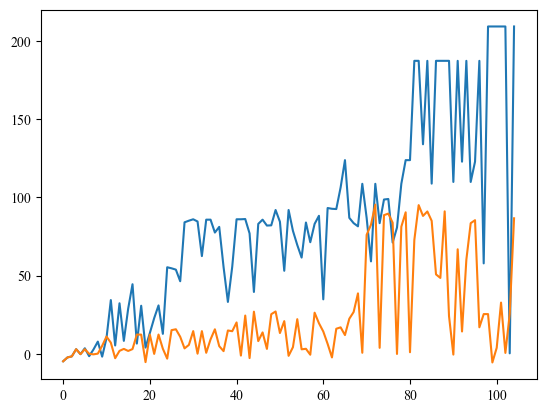

In [2]:
import matplotlib.pyplot as plt

# set plotting font to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Load results from csv
r = pd.read_csv('results_hea.csv')
results_hebo = r['hebo']
results_bo = r['bo']

plt.plot(results_hebo)
plt.plot(results_bo)

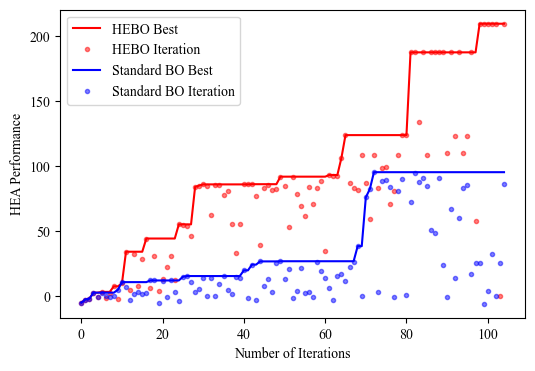

In [12]:
best_hebo = []
best_bo = []

for i in range(len(results_hebo)):
    best_hebo.append(max(results_hebo[:i+1]))
    best_bo.append(max(results_bo[:i+1]))

plt.figure(figsize=(6, 4))
plt.plot(best_hebo, label='HEBO Best', color='r')
plt.plot(results_hebo, '.', label='HEBO Iteration', alpha=0.5, color='r')
plt.plot(best_bo, label='Standard BO Best', color='b')
plt.plot(results_bo, '.', label='Standard BO Iteration', alpha=0.5, color='b')
plt.xlabel('Number of Iterations')
plt.ylabel('HEA Performance')
plt.legend()
plt.savefig('BO_results_for_HEA.pdf')